# 01. EDA — 데이터셋 3종 종합 탐색적 분석

**대상**: Multi-pose Dog Dataset(MPDD), DogFaceNet, 국가동물보호정보시스템(animal.go.kr) 실데이터

**목적**: 각 데이터셋의 특징을 시각화로 확인하고, 결측치·이상치·클래스 불균형을 점검한다.
(`scripts/preprocess_datasets.py`로 실제 처리한 결과를 이 노트북에서 시각적으로 재확인한다.)

| 파트 | 데이터셋 | 역할 |
|---|---|---|
| 1 | MPDD | 핵심 학습·평가 (전신·포즈) |
| 2 | DogFaceNet | 핵심 학습·평가 (얼굴 클로즈업) |
| 3 | 보호소 실데이터 | 데모 갤러리 + 도메인 갭 확인 (학습 미사용) |
| 4 | — | 전처리(결측치/이상치/불균형) 종합 |
| 5 | — | 종합 결론 |


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import laplace

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = PROJECT_ROOT / "docs" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MPDD_ROOT = PROJECT_ROOT / "Data" / "Multi-pose dog dataset" / "pytorch"
DFN_ROOT = PROJECT_ROOT / "Data" / "DogFaceNet"
SHELTER_ROOT = PROJECT_ROOT / "Data" / "shelter"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "AppleGothic"

rng = np.random.default_rng(42)


---
# Part 1. Multi-pose Dog Dataset (MPDD)

In [2]:
mpdd = pd.read_csv(PROJECT_ROOT / "metadata" / "multipose_dog_manifest_clean.csv")
mpdd["split"] = pd.Categorical(mpdd["split"], categories=["train", "val", "query", "gallery"], ordered=True)
mpdd.head()


,split,filename,relpath,dog_id,camera,sequence,frame,width,height,aspect_ratio,filesize_bytes,is_readable,is_low_res,usable_for_training
0,train,100_c1s6_1.jpg,train/100_c1s6_1.jpg,100,1,6,1,161,142,1.1338,6138,True,False,True
1,train,100_c1s6_5.jpg,train/100_c1s6_5.jpg,100,1,6,5,59,84,0.7024,2098,True,True,False
2,train,100_c2s5_7.jpg,train/100_c2s5_7.jpg,100,2,5,7,60,82,0.7317,2084,True,True,False
3,train,100_c3s2_2.jpg,train/100_c3s2_2.jpg,100,3,2,2,183,163,1.1227,14821,True,False,True
4,train,100_c3s5_8.jpg,train/100_c3s5_8.jpg,100,3,5,8,59,82,0.7195,2064,True,True,False


## 1.1 기본 통계 — split / ID / 카메라(포즈)

In [3]:
summary = mpdd.groupby("split", observed=True).agg(images=("filename", "count"), ids=("dog_id", "nunique"))
summary["images_per_id"] = (summary["images"] / summary["ids"]).round(2)
print(summary)

train_ids = set(mpdd.loc[mpdd.split == "train", "dog_id"])
test_ids = set(mpdd.loc[mpdd.split.isin(["query", "gallery"]), "dog_id"])
print(f"\n전체 고유 개체 수: {mpdd.dog_id.nunique()}")
print(f"train ∩ test ID 중복: {len(train_ids & test_ids)} (0이어야 올바른 open-set 분할)")


         images  ids  images_per_id
split                              
train       921   95           9.69
val         111   95           1.17
query       104   96           1.08
gallery     521   96           5.43

전체 고유 개체 수: 191
train ∩ test ID 중복: 0 (0이어야 올바른 open-set 분할)


**해석**: train(95 ID)과 query/gallery(96 ID)가 겹치지 않는 open-set 분할 — 모델이 한 번도 본 적 없는 개체를 구분해야 하는, 실제 서비스와 동일한 조건이다.

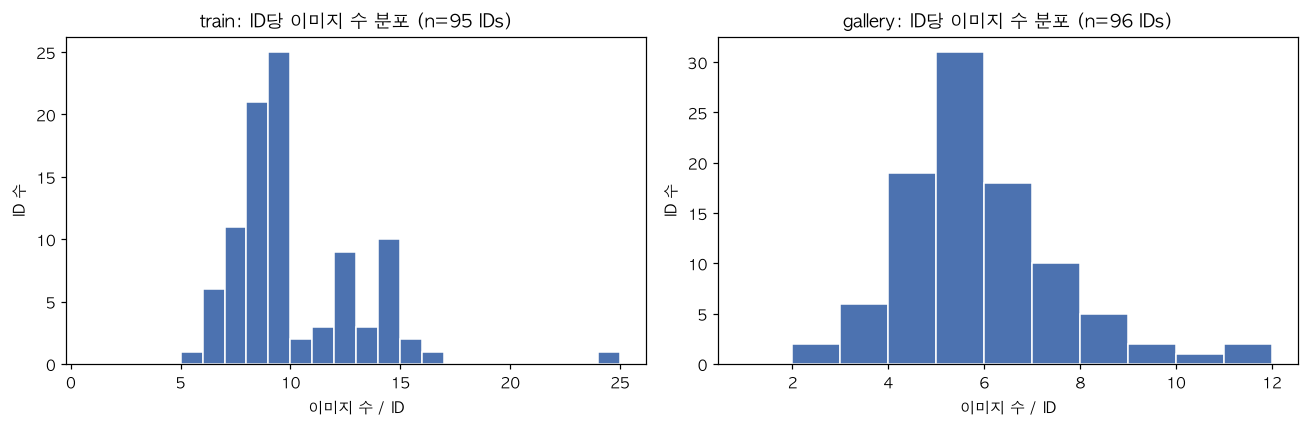

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
id_counts = mpdd.groupby(["split", "dog_id"], observed=True).size().reset_index(name="n")
for split, ax in zip(["train", "gallery"], axes):
    sub = id_counts[id_counts.split == split]["n"]
    ax.hist(sub, bins=range(1, sub.max() + 2), color="#4C72B0", edgecolor="white")
    ax.set_title(f"{split}: ID당 이미지 수 분포 (n={len(sub)} IDs)")
    ax.set_xlabel("이미지 수 / ID")
    ax.set_ylabel("ID 수")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_images_per_id.png")
plt.show()


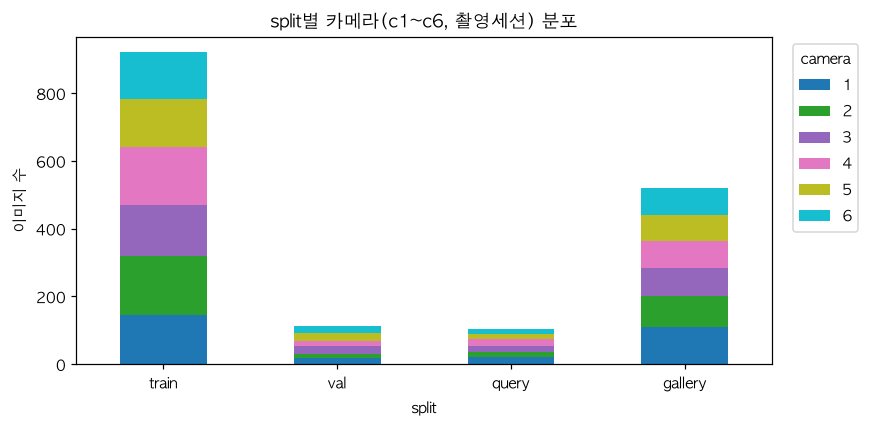

In [5]:
cam_dist = mpdd.groupby(["split", "camera"], observed=True).size().unstack(fill_value=0)
cam_dist = cam_dist.reindex(["train", "val", "query", "gallery"])
cam_dist.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="tab10")
plt.title("split별 카메라(c1~c6, 촬영세션) 분포")
plt.ylabel("이미지 수")
plt.xticks(rotation=0)
plt.legend(title="camera", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_camera_distribution.png")
plt.show()


## 1.2 이미지 크기 — 저해상도 문제 정량화

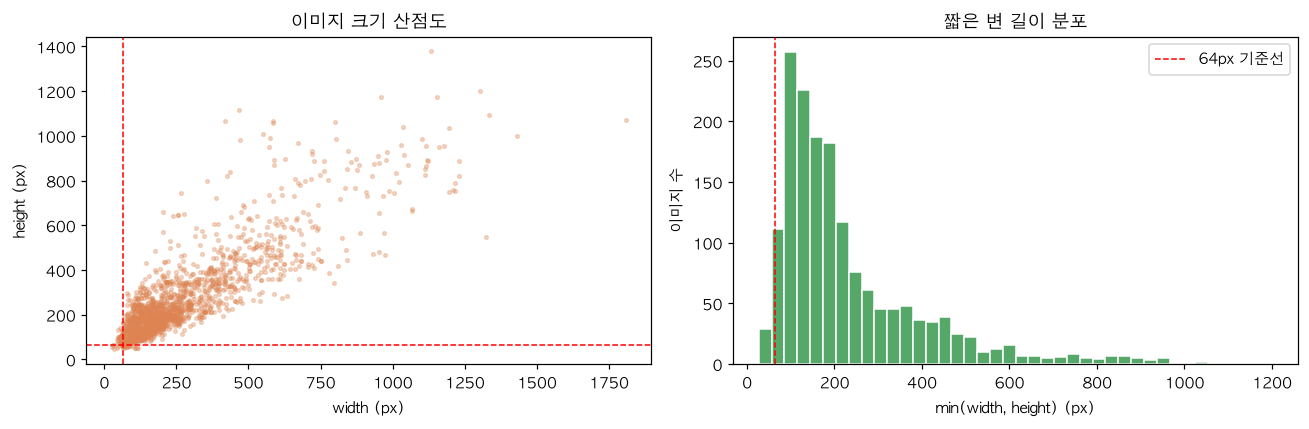

짧은 변 < 64px 인 이미지: 52장 (3.1%)
짧은 변 < 96px 인 이미지: 221장 (13.3%)
짧은 변 < 128px 인 이미지: 507장 (30.6%)
짧은 변 < 160px 인 이미지: 729장 (44.0%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(mpdd["width"], mpdd["height"], s=6, alpha=0.3, c="#DD8452")
axes[0].set_xlabel("width (px)"); axes[0].set_ylabel("height (px)")
axes[0].set_title("이미지 크기 산점도")
axes[0].axvline(64, color="red", ls="--", lw=1); axes[0].axhline(64, color="red", ls="--", lw=1)

min_side = mpdd[["width", "height"]].min(axis=1)
axes[1].hist(min_side, bins=40, color="#55A868", edgecolor="white")
axes[1].axvline(64, color="red", ls="--", lw=1, label="64px 기준선")
axes[1].set_xlabel("min(width, height) (px)"); axes[1].set_ylabel("이미지 수")
axes[1].set_title("짧은 변 길이 분포")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "03_image_size.png")
plt.show()

for thr in [64, 96, 128, 160]:
    n = (min_side < thr).sum()
    print(f"짧은 변 < {thr}px 인 이미지: {n}장 ({n/len(mpdd)*100:.1f}%)")


## 1.3 개체 내(intra-ID) 시각적 변이 — 같은 개, 다른 자세/카메라

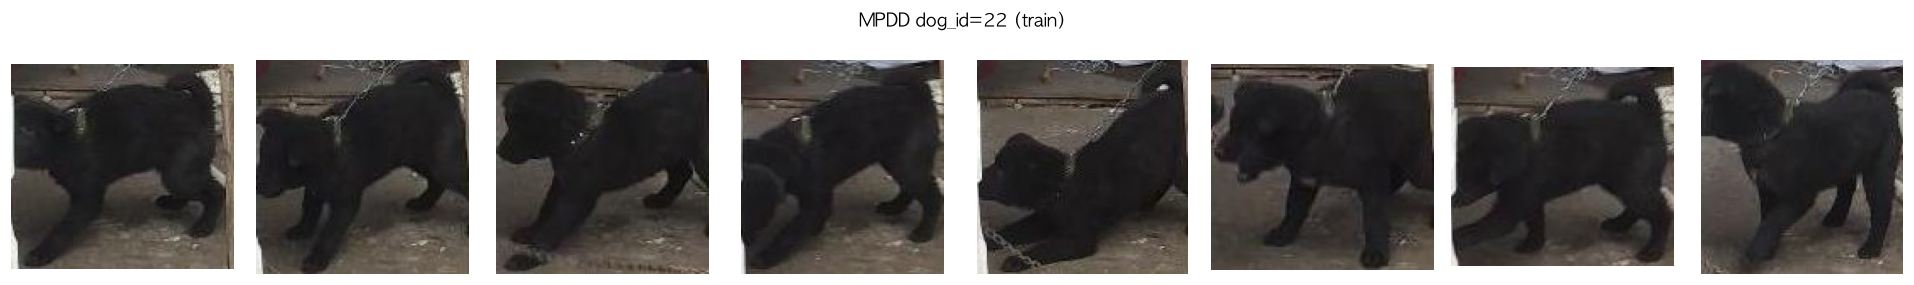

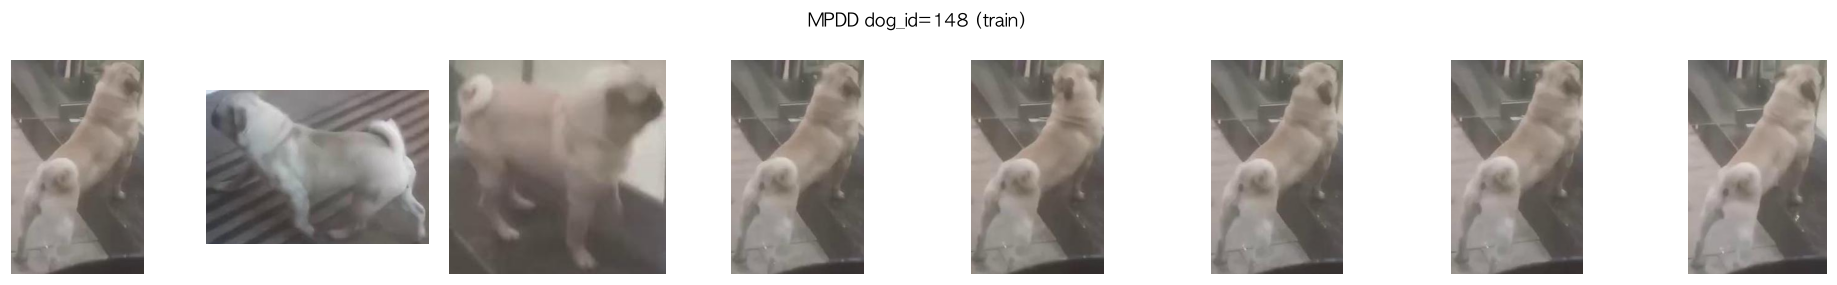

In [7]:
def show_id_grid(df, root, dog_id, split_col, split_val, id_col="dog_id", n=8, title=""):
    rows = df[(df[id_col] == dog_id) & (df[split_col] == split_val)].head(n)
    fig, axes = plt.subplots(1, len(rows), figsize=(2.2 * len(rows), 2.6))
    if len(rows) == 1:
        axes = [axes]
    for ax, (_, r) in zip(axes, rows.iterrows()):
        img = Image.open(root / r.relpath)
        ax.imshow(img)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    return fig

sample_ids = rng.choice(sorted(mpdd[mpdd.split == "train"].dog_id.unique()), size=2, replace=False)
for i, did in enumerate(sample_ids):
    fig = show_id_grid(mpdd, MPDD_ROOT, int(did), "split", "train", n=8, title=f"MPDD dog_id={did} (train)")
    fig.savefig(FIG_DIR / f"04_intraid_sample_{i}.png")
    plt.show()


**해석**: 같은 개체라도 자세·각도·거리·조명에 따라 외형 변화가 크다 — 포즈에 강건한 임베딩(메트릭 러닝)이 필요.

## 1.4 선명도(블러) 체크

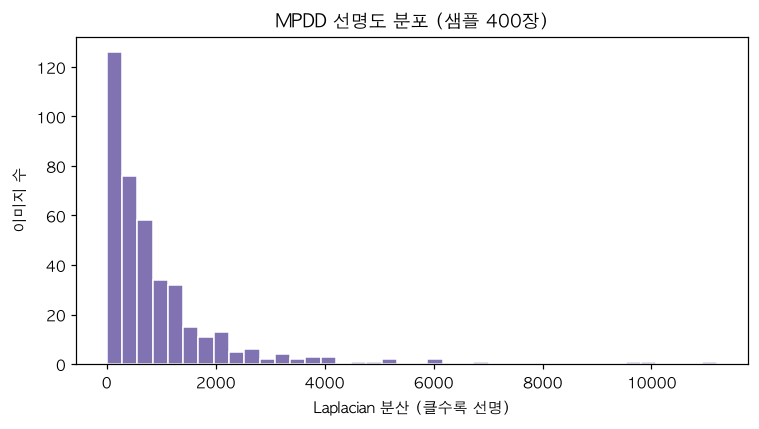

In [8]:
def sharpness(path, max_side=256):
    img = Image.open(path).convert("L")
    img.thumbnail((max_side, max_side))
    return laplace(np.asarray(img, dtype=np.float64)).var()

sample_n = min(400, len(mpdd))
mpdd_sample = mpdd.sample(sample_n, random_state=0).copy()
mpdd_sample["sharpness"] = [sharpness(MPDD_ROOT / rp) for rp in mpdd_sample["relpath"]]

plt.figure(figsize=(7, 4))
plt.hist(mpdd_sample["sharpness"], bins=40, color="#8172B2", edgecolor="white")
plt.xlabel("Laplacian 분산 (클수록 선명)"); plt.ylabel("이미지 수")
plt.title(f"MPDD 선명도 분포 (샘플 {sample_n}장)")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_sharpness.png")
plt.show()


## 1.5 MPDD 요약
- 191개체 / 1,657장, train(95 ID)·test(96 ID) 완전 분리된 open-set 분할
- 짧은 변 128px 미만 30.6%, 64px 미만 3.1% → 저해상도 대응 필요 (→ Part 4 전처리에서 실제 처리)
- 실외 환경에서 찍힌 믹스견 위주 — 실제 보호소 사진과 결이 비슷함


---
# Part 2. DogFaceNet (얼굴 클로즈업)

In [9]:
dfn = pd.read_csv(PROJECT_ROOT / "metadata" / "dogfacenet_manifest_clean.csv")
dfn.head()


,split_group,filename,relpath,dog_id,width,height,is_readable,is_low_res,usable_for_training
0,train,0_1.jpg,images/0_1.jpg,0,224,224,True,False,True
1,train,0_2.jpg,images/0_2.jpg,0,224,224,True,False,True
2,train,0_3.jpg,images/0_3.jpg,0,224,224,True,False,True
3,train,0_4.jpg,images/0_4.jpg,0,224,224,True,False,True
4,train,0_5.jpg,images/0_5.jpg,0,224,224,True,False,True


## 2.1 기본 통계

In [10]:
print(f"전체 이미지: {len(dfn)}장, 전체 개체: {dfn.dog_id.nunique()}개")
print(dfn.groupby("split_group")["dog_id"].nunique())

per_class = dfn.groupby("dog_id").size()
print(f"\n개체당 이미지 수: min={per_class.min()} max={per_class.max()} "
      f"중앙값={per_class.median():.0f} 평균={per_class.mean():.2f}")


전체 이미지: 8363장, 전체 개체: 1393개
split_group
test      278
train    1115
Name: dog_id, dtype: int64

개체당 이미지 수: min=2 max=41 중앙값=5 평균=6.00


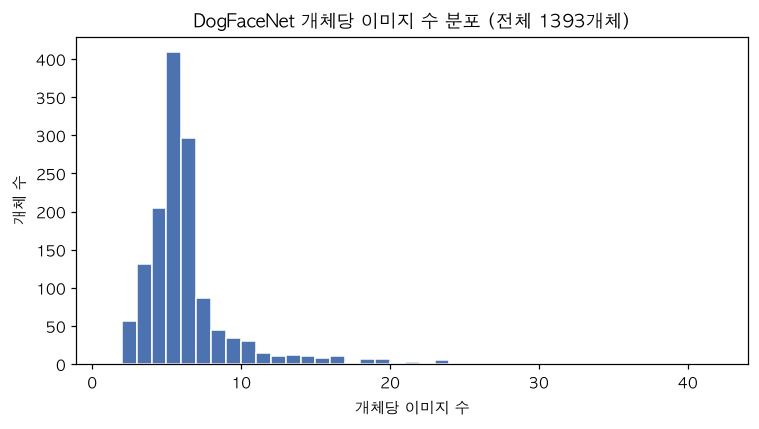

In [11]:
plt.figure(figsize=(7, 4))
plt.hist(per_class, bins=range(1, per_class.max() + 2), color="#4C72B0", edgecolor="white")
plt.xlabel("개체당 이미지 수"); plt.ylabel("개체 수")
plt.title(f"DogFaceNet 개체당 이미지 수 분포 (전체 {dfn.dog_id.nunique()}개체)")
plt.tight_layout()
plt.savefig(FIG_DIR / "09_dogfacenet_per_class_hist.png")
plt.show()


**해석**: 대부분 4~6장에 몰려있고 최대 41장까지 긴 꼬리 — 전형적인 롱테일 분포. 개체당 샘플이 극히 적어(중앙값 5장) 일반 분류 학습보다 메타러닝(Prototypical Network)이 유리하다는 선행연구(D1.7, `docs/references/`) 결론과 일치한다.

## 2.2 이미지 크기 확인 (이미 정렬된 224×224인지)

In [12]:
print(dfn[["width", "height"]].describe())
n_not_224 = ((dfn.width != 224) | (dfn.height != 224)).sum()
print(f"224x224가 아닌 이미지: {n_not_224}장")


        width  height
count  8363.0  8363.0
mean    224.0   224.0
std       0.0     0.0
min     224.0   224.0
25%     224.0   224.0
50%     224.0   224.0
75%     224.0   224.0
max     224.0   224.0
224x224가 아닌 이미지: 0장


## 2.3 개체별 얼굴 샘플

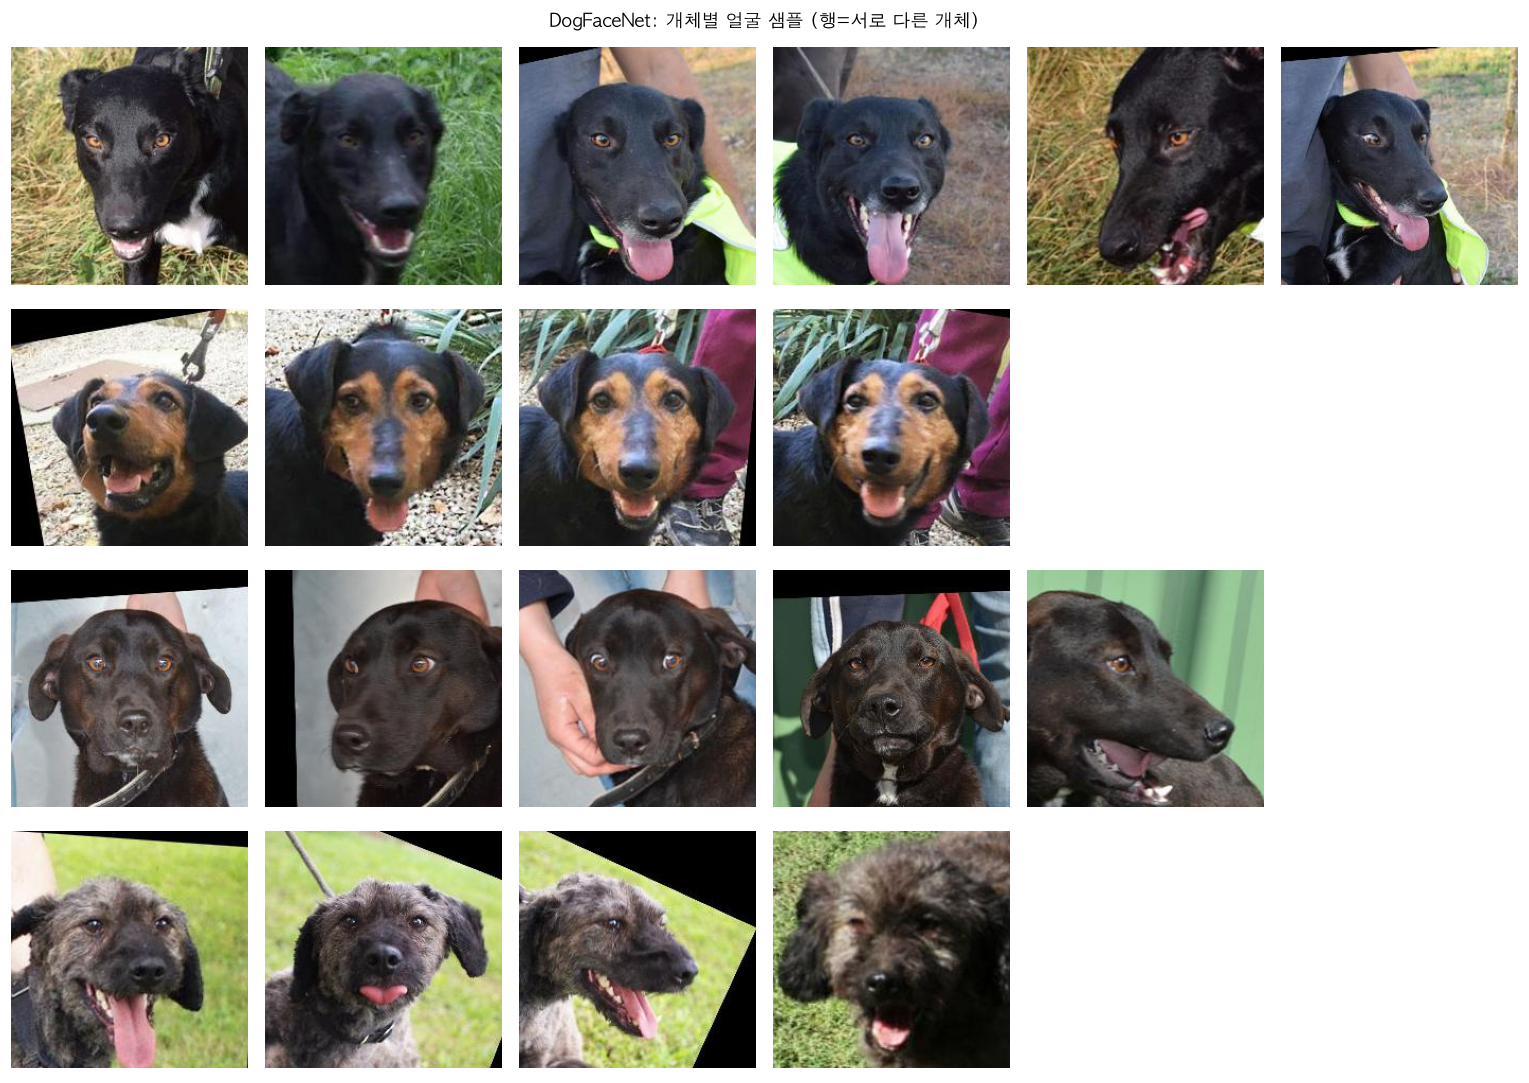

In [13]:
sample_ids = rng.choice(sorted(dfn.dog_id.unique()), size=4, replace=False)
fig, axes = plt.subplots(4, 6, figsize=(14, 10))
for row_i, did in enumerate(sample_ids):
    sub = dfn[dfn.dog_id == did].head(6)
    for col_i in range(6):
        ax = axes[row_i, col_i]
        if col_i < len(sub):
            r = sub.iloc[col_i]
            img = Image.open(DFN_ROOT / r.relpath)
            ax.imshow(img)
        ax.axis("off")
plt.suptitle("DogFaceNet: 개체별 얼굴 샘플 (행=서로 다른 개체)")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_dogfacenet_sample.png")
plt.show()


## 2.4 DogFaceNet 요약
- 1,393개체 / 8,363장, 이미 정렬된 224×224 얼굴 크롭
- 개체당 2~41장(중앙값 5장) — MPDD보다 개체 수는 7배 많지만 개체당 샘플은 훨씬 적음 (상호보완적)
- 얼굴 정렬 과정에서 생긴 검은 모서리 패딩이 일부 관찰됨 (학습 시 random crop으로 완화 예정)


---
# Part 3. 국가동물보호정보시스템 실데이터 (animal.go.kr)

In [14]:
shelter_path = PROJECT_ROOT / "metadata" / "shelter_manifest_clean.csv"
if shelter_path.exists():
    shelter = pd.read_csv(shelter_path)
    print(f"전체 공고: {len(shelter)}건")
    shelter.head()
else:
    shelter = None
    print("[skip] shelter_manifest_clean.csv 없음")


전체 공고: 1450건


## 3.1 품종 분포

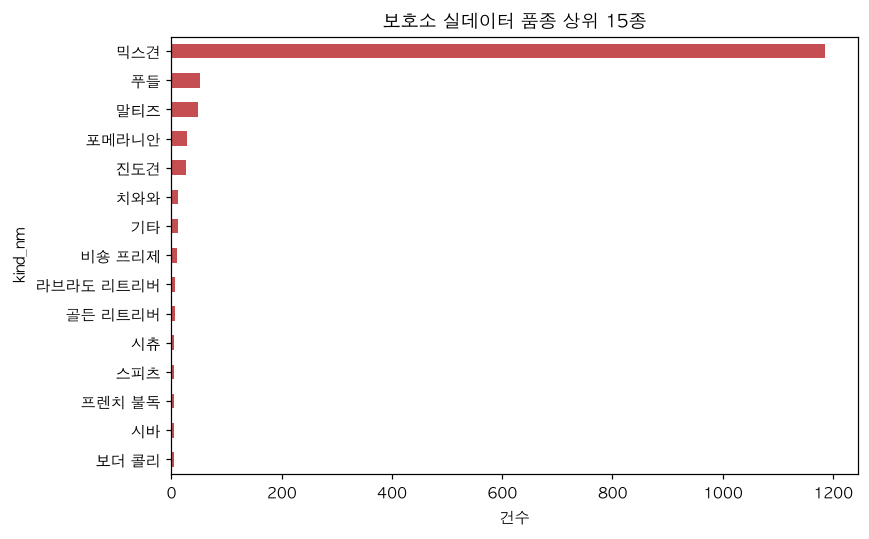

믹스견 비율: 81.8%


In [15]:
if shelter is not None:
    breed_counts = shelter.kind_nm.value_counts().head(15)
    plt.figure(figsize=(8, 5))
    breed_counts.iloc[::-1].plot(kind="barh", color="#C44E52")
    plt.xlabel("건수"); plt.title("보호소 실데이터 품종 상위 15종")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "10_shelter_breed_dist.png")
    plt.show()

    mix_ratio = (shelter.kind_nm == "믹스견").mean()
    print(f"믹스견 비율: {mix_ratio*100:.1f}%")


**해석**: 믹스견이 압도적 다수 — 순종 품종 분류의 실효성이 낮아, 품종은 하드 필터가 아니라 재순위용 소프트 신호로만 쓰기로 한 기존 결정(D1)이 데이터로 재확인된다.

## 3.2 지역 분포

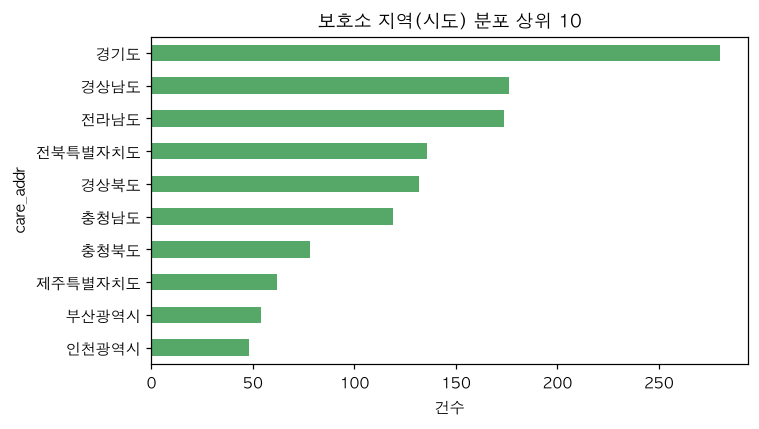

In [16]:
if shelter is not None:
    region = shelter.care_addr.dropna().apply(lambda s: s.split()[0] if s else "").value_counts().head(10)
    plt.figure(figsize=(7, 4))
    region.iloc[::-1].plot(kind="barh", color="#55A868")
    plt.xlabel("건수"); plt.title("보호소 지역(시도) 분포 상위 10")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "11_shelter_region_dist.png")
    plt.show()


## 3.3 실제 사진 샘플 — 도메인 갭 확인

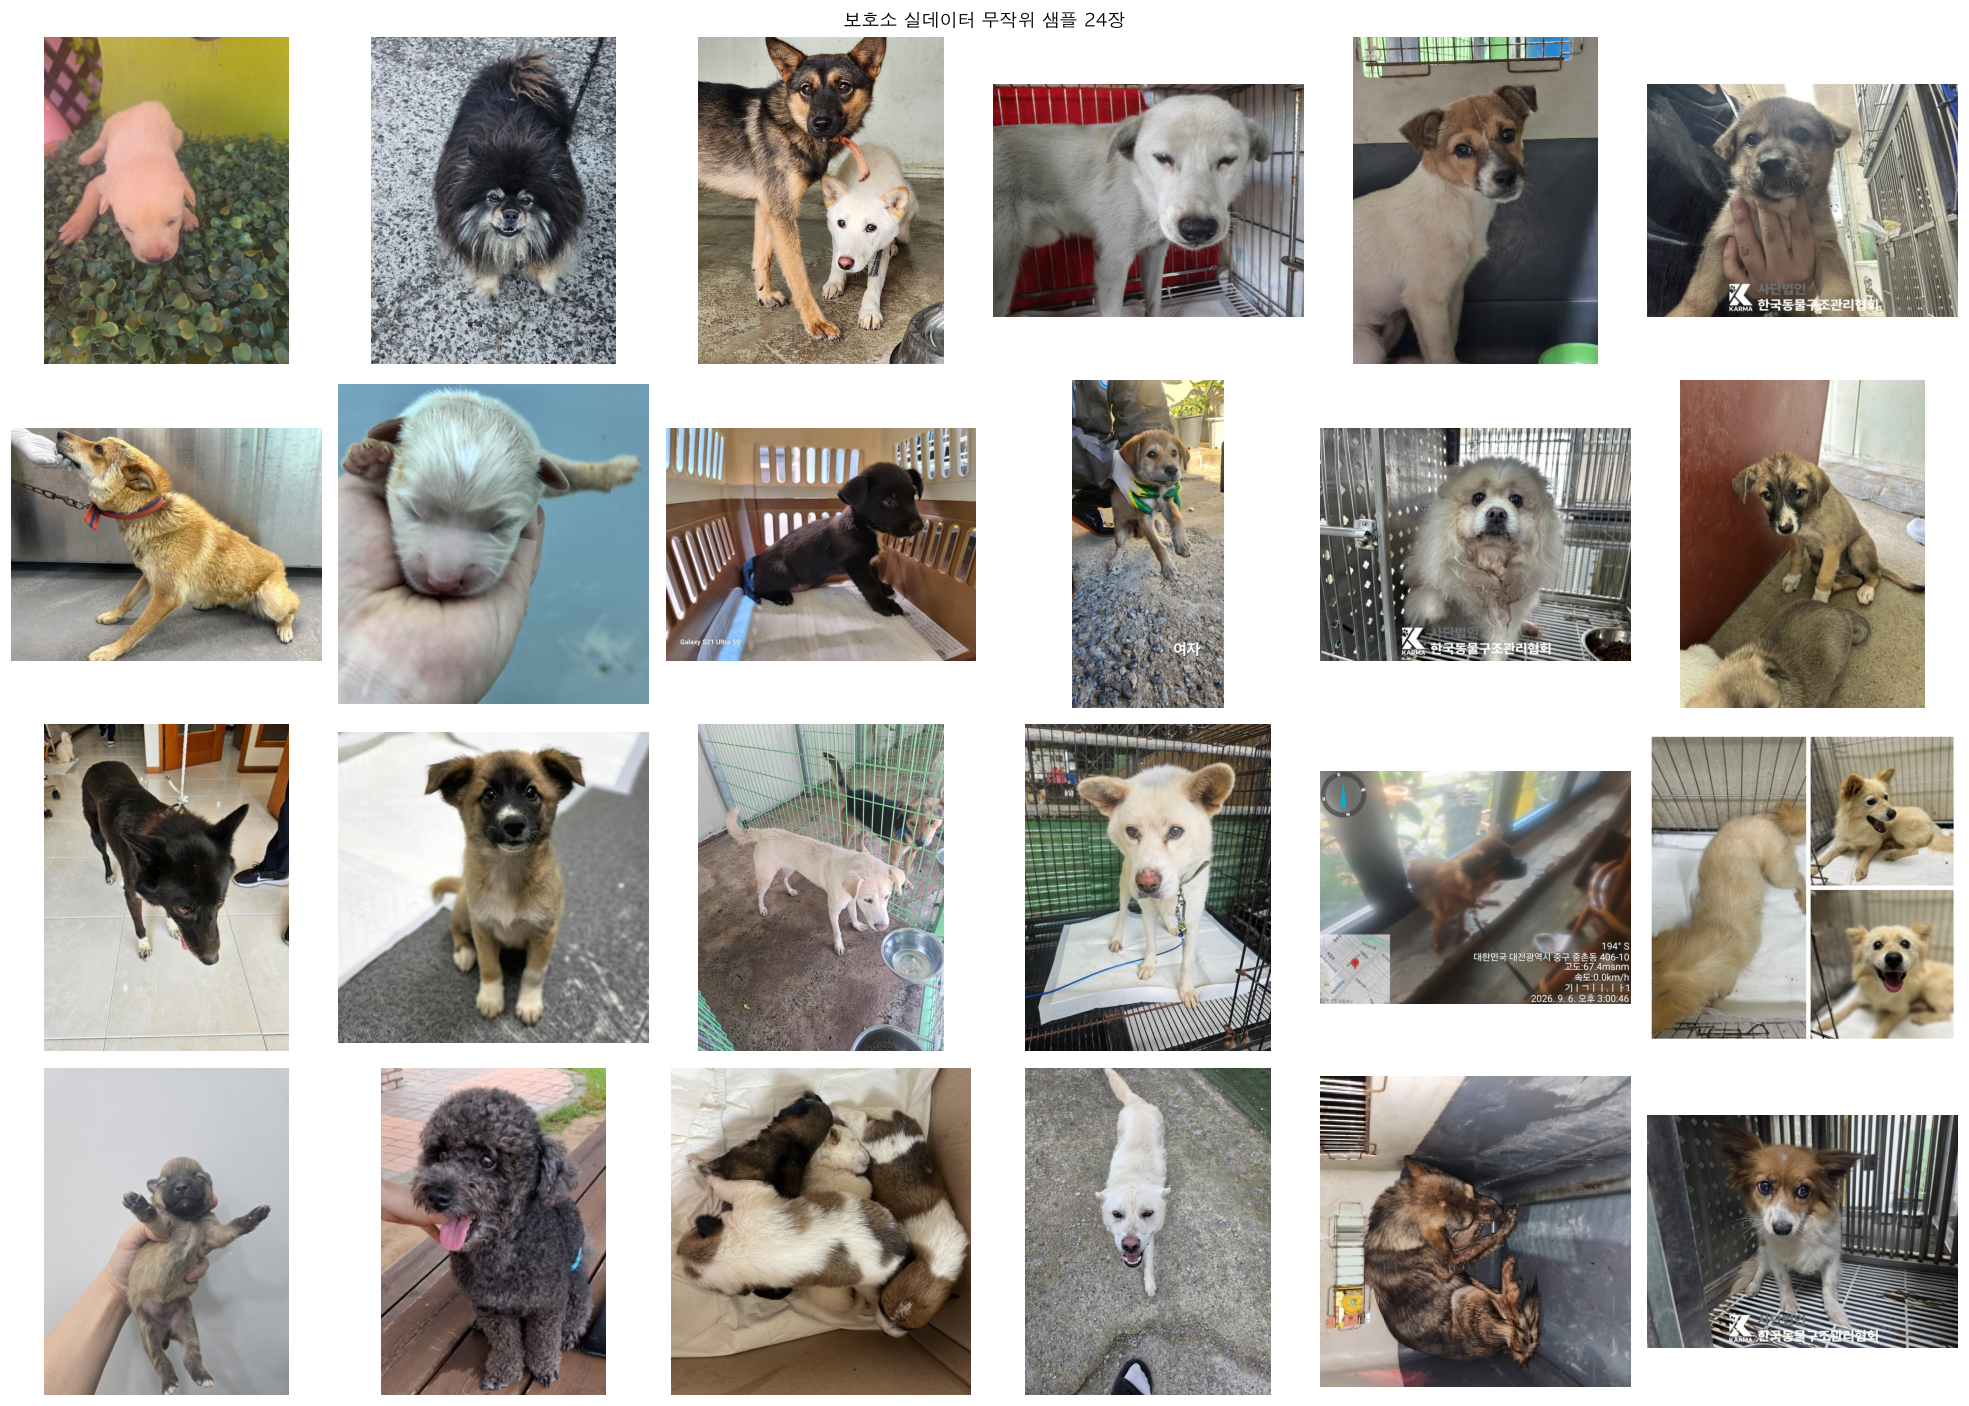

In [17]:
if shelter is not None:
    all_photos = []
    for paths in shelter.photo_local_paths.dropna():
        all_photos.extend([p for p in str(paths).split("|") if p])
    sample_photos = rng.choice(all_photos, size=min(24, len(all_photos)), replace=False)

    fig, axes = plt.subplots(4, 6, figsize=(18, 13))
    for ax, rel in zip(axes.flat, sample_photos):
        try:
            img = Image.open(SHELTER_ROOT / rel)
            ax.imshow(img)
        except Exception:
            pass
        ax.axis("off")
    plt.suptitle("보호소 실데이터 무작위 샘플 24장")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "07_shelter_sample_grid.png")
    plt.show()


**해석**: MPDD·DogFaceNet(정돈된 학습용 사진)과 달리, 실제 보호소 사진은 사람 팔이 같이 나오거나
이모지 스티커로 얼굴이 가려지고 배경이 어수선한 경우가 많다. 약 1/3은 얼굴 클로즈업, 2/3은 전신 —
DogFaceNet(얼굴)과 MPDD(전신)를 함께 학습에 쓰기로 한 결정(D1.6)이 이 실사진 구성과 맞아떨어진다.
개 탐지·크롭 전처리 없이는 사람 팔·배경이 임베딩을 오염시킬 수 있다는 게 이 샘플에서 확인된
실질적 위험이다.

## 3.4 보호소 데이터 요약
- 유기견 1,450건(전처리 후, 사진없는 14건 제거), 사진 2,899장
- 믹스견 81.8%, 품종 40종
- 실제 도메인 갭(스티커/사람팔/배경) 확인 — 학습엔 안 쓰고 D5 데모 갤러리 + 도메인 테스트용으로만 사용


---
# Part 4. 전처리(결측치·이상치·클래스 불균형) 종합

`scripts/preprocess_datasets.py` 실행 결과를 시각적으로 재확인한다.

         데이터셋  원본 건수  제거/플래그 건수  처리 후
0        MPDD   1657         52  1605
1  DogFaceNet   8363          0  8363
2         보호소   1464         14  1450


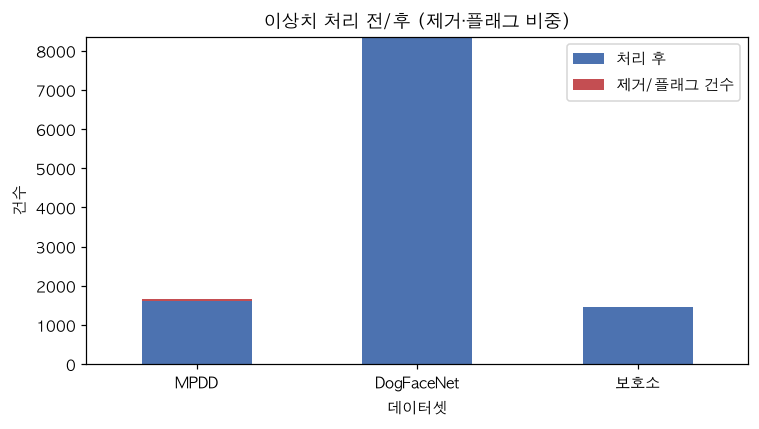

In [18]:
outlier_summary = pd.DataFrame({
    "데이터셋": ["MPDD", "DogFaceNet", "보호소"],
    "원본 건수": [1657, 8363, 1464],
    "제거/플래그 건수": [
        int((~mpdd.usable_for_training).sum()) if "usable_for_training" in mpdd else 52,
        int((~dfn.usable_for_training).sum()) if "usable_for_training" in dfn else 0,
        1464 - len(shelter) if shelter is not None else 14,
    ],
})
outlier_summary["처리 후"] = outlier_summary["원본 건수"] - outlier_summary["제거/플래그 건수"]
print(outlier_summary)

outlier_summary.set_index("데이터셋")[["처리 후", "제거/플래그 건수"]].plot(
    kind="bar", stacked=True, figsize=(7, 4), color=["#4C72B0", "#C44E52"]
)
plt.ylabel("건수"); plt.title("이상치 처리 전/후 (제거·플래그 비중)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "12_outlier_summary.png")
plt.show()


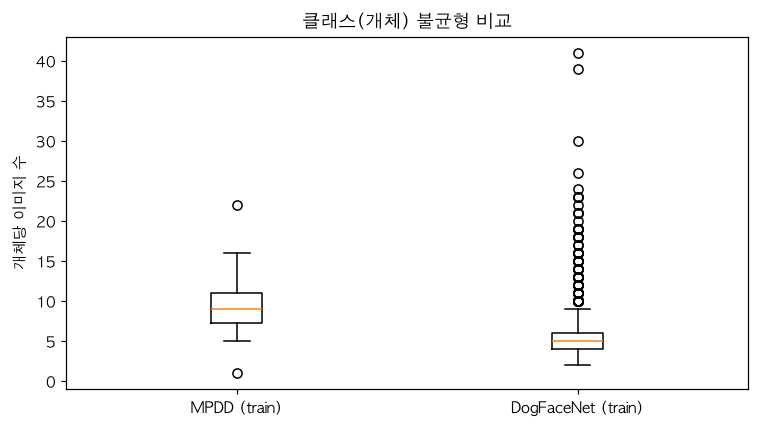

MPDD 불균형비: 22.0배
DogFaceNet 불균형비: 20.5배


In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
mpdd_per_id = mpdd[(mpdd.split == "train") & mpdd.usable_for_training].groupby("dog_id").size()
dfn_per_id = dfn[dfn.split_group == "train"].groupby("dog_id").size()
ax.boxplot([mpdd_per_id, dfn_per_id], tick_labels=["MPDD (train)", "DogFaceNet (train)"])
ax.set_ylabel("개체당 이미지 수")
ax.set_title("클래스(개체) 불균형 비교")
plt.tight_layout()
plt.savefig(FIG_DIR / "13_class_imbalance_boxplot.png")
plt.show()

print(f"MPDD 불균형비: {mpdd_per_id.max()/mpdd_per_id.min():.1f}배")
print(f"DogFaceNet 불균형비: {dfn_per_id.max()/dfn_per_id.min():.1f}배")


**전처리 결론**
- 결측치: 이미지 손상 0건, 보호소 텍스트 필드 결측 0건 (직접 검증)
- 이상치: MPDD 저해상도 52장 학습제외 플래그, 보호소 사진없는 공고 14건 제거
- 클래스 불균형: MPDD 최대 22배, DogFaceNet 최대 20배 → E1은 WeightedRandomSampler,
  E2(Prototypical Network)는 에피소드 균일 샘플링으로 구조적 대응


---
# Part 5. 종합 결론 (데이터 선정 확정 근거)

1. **MPDD + DogFaceNet을 핵심 학습·평가 데이터로 확정.** 전신·포즈(MPDD)와 얼굴 클로즈업
   (DogFaceNet)이 상호보완적이며, 실제 보호소 사진(Part 3)이 이 두 유형을 섞어놓은 형태라는 것을
   시각적으로 확인했다.
2. **개체당 샘플이 매우 적은 소수샷(few-shot) 환경**임을 두 데이터셋 모두에서 확인 (MPDD 최대 22배,
   DogFaceNet 최대 20배 불균형) → 메타러닝(Prototypical Network) 채택의 데이터 근거.
3. **보호소 실데이터는 학습에 쓰지 않고 데모·도메인 테스트 전용**으로 확정 — 정돈된 학습 데이터와
   실제 사진 사이의 눈에 띄는 도메인 갭(사람 팔, 스티커, 배경)을 직접 확인했기 때문.
4. 결측치·이상치·클래스 불균형을 실제 코드로 점검·처리하여 "전처리 후" 데이터셋을 확보했다
   (`metadata/*_manifest_clean.csv`).

**다음 단계**: E1(CE 파인튜닝) → E2(Prototypical Network) 학습, MPDD·DogFaceNet 양쪽 테스트셋에서
CMC/mAP 비교.
